# Flow and motion in balanced SSFP

Balanced SSFP is often described as robust against flow and motion. Bieri and Scheffler open
their 2005 paper by noting that it "is often believed to be insensitive and robust against flow
or motion, and until recently little was known about the effects of flow or motion on steady-state
acquisitions" — and then show that the belief needs qualifying.

This notebook asks what conventional balanced SSFP actually does in the presence of constant-
velocity flow, and when explicit gradient-moment nulling adds something. It takes the physics
from the literature first and then measures this implementation against it, keeping the three
kinds of statement apart throughout:

```text
literature establishes    what the papers derive or report
measurement shows         what this implementation's emitted waveform or simulation gives
interpretation            what we read into the two together, scoped to what was measured
```

## What the literature says

**The steady-state condition is that the per-TR phase be constant, not zero.** Bieri and
Scheffler's Eq. [1]: the accumulated spin phase $\varphi(n)$ within the $n$-th TR interval must
satisfy $\varphi(n) = \varphi(n+1)$ for the magnetisation to stay in a steady state. Anything
that varies the phase from one repetition to the next perturbs it.

**For a moving spin, what varies is the phase-encode first moment.** They state that "the time
integral over the readout and slice selection gradient (for the 2D case) is zero- and first-order
flow-compensated within each TR interval", while "PE leads to a nonconstant spin phase evolution
due to changing first-order moments". Their Eq. [2] gives the increment between successive
encoding steps:

$$\Delta\varphi_{PE}(n \to n+1) = \gamma\, v_{PE} \int_0^{TR}\left[G_{PE}(n+1,t) - G_{PE}(n,t)\right] t\,\mathrm{d}t$$

**How much is too much.** Their simulations put the onset of steady-state signal loss at roughly
$\Delta\varphi_{PE} \approx 1°$ and significant perturbation above $2°$. For standard 2D
parameters (FOV 300 mm, TR 5 ms, $256^2$) they evaluate the increment at about
$2°/(\mathrm{m/s})$, which puts the critical velocity for linear view ordering at roughly
0.5–1 m/s.

**Flow is not one mechanism.** Markl and Pelc's companion study attributes much of the
flow-related signal change in balanced SSFP to *outflow*: spins that have left the imaging slice
but still contribute, broadening the effective slice by as much as 15× and producing
frequency-offset-dependent enhancement. That mechanism is about through-slice transport and slice
profile, not about gradient moments, and nothing in this notebook measures it.

This notebook is about the gradient-moment mechanism only.

In [1]:
import os

SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 60
warnings.filterwarnings('ignore', message='To copy construct from a tensor')

SEQ_DIR = Path('seq')
#: Every file this notebook writes is a probe -- one k-space line read many times, to isolate a
#: moment or a view order.  None of them is an acquisition, and none of them implements the
#: between-excitations condition Part C describes, so they are named for what they measure and
#: kept out of `seq/`, which holds the two acquisitions `01` wrote.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

opts = pp.Opts(
    max_grad=24, grad_unit='mT/m', max_slew=120, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)
FOV_MM, MATRIX, THICKNESS_MM = 250.0, (64, 64), 6.0
FLIP_DEG, BANDWIDTH_HZ_PX = 40.0, 700.0
NX, NY = MATRIX
CENTRE_LINE = NY // 2

PROTOCOL = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX)

conventional = sc.modules.bSSFP2DTR(**PROTOCOL)
print(f'conventional bSSFP   TE {conventional.te_s * 1e3:.3f} ms   '
      f'TR {conventional.tr_s * 1e3:.3f} ms   flip {FLIP_DEG:.0f} deg')
print(f'FOV {FOV_MM:.0f} mm, {NX} x {NY}, {THICKNESS_MM:.0f} mm slice')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


conventional bSSFP   TE 3.225 ms   TR 6.450 ms   flip 40 deg
FOV 250 mm, 64 x 64, 6 mm slice


## Part A — what conventional balanced SSFP does

### A1. The moments this implementation actually has

Measured on the emitted waveform: compile a short train, find the RF effective centres, and
integrate each axis over the two intervals that matter.

The two intervals mean different things, and conflating them is the usual mistake:

```text
at the echo          M0 is the intended k-space position, so M0y carries ky and is NOT zero
                     M1 is velocity sensitivity in that acquired line's phase

over RF-to-RF        M0 = 0 is the balanced-SSFP condition
                     M1 need not be zero, and what matters is how much it CHANGES between
                     consecutive repetitions (Bieri Eq. [2])
```

In [2]:
def rf_centres(seq):
    """Absolute time of every RF effective centre, seconds."""
    out, t = [], 0.0
    for i in range(1, len(seq.block_events) + 1):
        block = seq.get_block(i)
        if getattr(block, 'rf', None) is not None:
            out.append(t + float(block.rf.delay) + float(pp.calc_rf_center(block.rf)[0]))
        t += float(seq.block_durations[i])
    return np.array(out)


def moment(seq, start, end, origin, order):
    """``(Mx, My, Mz)`` of the given order over ``[start, end]``, about `origin`."""
    waveforms = seq.waveforms_and_times()[0]
    out = []
    for axis in range(3):
        t, g = waveforms[axis][0], waveforms[axis][1]
        if len(t) == 0:
            out.append(0.0)
            continue
        grid = np.unique(np.concatenate([t[(t > start) & (t < end)], [start, end]]))
        v = np.interp(grid, t, g, left=0.0, right=0.0)
        out.append(float(np.trapezoid(v * (grid - origin) ** order, grid)))
    return np.array(out)


def measure(kernel, line):
    """Moments of one repetition, at the echo and over the RF-to-RF interval."""
    scan = sc.LogicBlock()
    for index in range(3):
        scan.add(index * kernel.tr_s,
                 kernel(line=(line + index) % NY, phase_deg=180.0 * (index % 2)))
    seq = sc.compile(scan, opts)
    c = rf_centres(seq)
    return {
        'm0_te': moment(seq, c[0], c[0] + kernel.te_s, c[0], 0),
        'm1_te': moment(seq, c[0], c[0] + kernel.te_s, c[0], 1),
        'm0_rr': moment(seq, c[0], c[1], c[0], 0),
        'm1_rr': moment(seq, c[0], c[1], c[0], 1),
    }


print(f'{"":34}{"x":>13}{"y":>13}{"z":>13}')
for line in (0, CENTRE_LINE, NY - 1):
    m = measure(conventional, line)
    print(f'ky line {line:2d}')
    for key, label, unit in (('m0_te', '  M0 at the echo', '1/m'),
                             ('m1_te', '  M1 at the echo', 's/m'),
                             ('m0_rr', '  M0 over RF-to-RF', '1/m'),
                             ('m1_rr', '  M1 over RF-to-RF', 's/m')):
        print(f'{label:34}' + ''.join(f'{v:13.4e}' for v in m[key]) + f'   {unit}')

                                              x            y            z
ky line  0
  M0 at the echo                    -4.5475e-13  -1.2800e+02   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02  -2.9312e-01  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-to-RF                   3.2354e-03   2.3680e-01  -2.2204e-16   s/m
ky line 32
  M0 at the echo                    -4.5475e-13   0.0000e+00   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02   0.0000e+00  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-to-RF                   3.2354e-03   0.0000e+00  -2.2204e-16   s/m
ky line 63
  M0 at the echo                    -4.5475e-13   1.2400e+02   3.8369e-13   1/m
  M1 at the echo                     7.5162e-02   2.8396e-01  -3.7539e-01   s/m
  M0 over RF-to-RF                  -7.6028e-13   0.0000e+00   2.2737e-13   1/m
  M1 over RF-

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

```text
measurement shows    M0 over RF-to-RF is zero on all three axes -- the balance condition.
                     M0 at the echo is zero on x and z and carries ky on y, as encoding requires.

                     M1 over RF-to-RF:  z is zero to 2e-16
                                        x is 3.2e-3 s/m and the SAME for every line
                                        y varies with the line, through zero at ky = 0

                     M1 at the echo is non-zero on all three axes.
```

That is the structure Bieri and Scheffler assume: "the time integral over the readout and slice
selection gradient (for the 2D case) is zero- and first-order flow-compensated within each TR
interval", while "PE leads to a nonconstant spin phase evolution due to changing first-order
moments".

**Zero net area does not produce that on its own.** It says nothing about *where* in the interval
the area was played, and the first moment is exactly that. What produces it is arranging each
axis symmetrically about the echo — on `z`, each balancing lobe sitting the same distance from
its own RF centre, which needs a small pad because the transmit dead time makes the pulse's two
halves unequal. The repetition is built that way; a waveform that merely satisfied `M0 = 0` would
not be.

`M1x` is not exactly zero, and the reason is visible in the readout: the prephaser cancels the
area before the echo and the balancing lobe the area after it, and the half-dwell offset of the
echo sample makes those differ a little, so the two lobes mirror in time but not quite in area.
It is 1.16°/(m/s) and it is the **same for every line** — which, by Eq. [1], is the thing that
matters: a constant per-TR phase leaves a steady state alone.

Because `M0` over the interval is zero, `M1` over that interval has the same value whatever
reference time it is taken about — the two differ by `(t_ref1 − t_ref2)·M0`. So "the first moment
between excitations" is unambiguous, which is what makes it a usable condition.

### A2. The quantity the literature says governs steady state

Bieri and Scheffler's Eq. [2] is a *difference* between consecutive repetitions, not an absolute
moment. On the phase-encode axis `M1` over the interval is linear in the line index, so the
increment is set by how far apart in k-space two consecutively acquired lines are — which is view
ordering, and view ordering is written in the acquisition rather than in the repetition.

In [3]:
m1y_of = {line: measure(conventional, line)['m1_rr'][1] for line in (0, CENTRE_LINE)}
slope = (m1y_of[CENTRE_LINE] - m1y_of[0]) / CENTRE_LINE       # s/m per line
intercept = m1y_of[0]
print(f'M1y over RF-to-RF is linear in the line index: {slope:+.4e} s/m per line')


def phi_increment_deg_per_m_s(order):
    """Bieri Eq. [2] for a view order: |phase increment| between consecutive acquired lines."""
    m1 = intercept + slope * np.asarray(order, dtype=float)
    return np.degrees(2 * np.pi * np.abs(np.diff(m1)))


linear = list(range(NY))
centric = sorted(range(NY), key=lambda k: (abs(k - CENTRE_LINE), k))
paired = []
for k in centric:
    if k in paired:
        continue
    paired.append(k)
    partner = k + 1 if (k + 1 < NY and k + 1 not in paired) else k - 1
    if 0 <= partner < NY and partner not in paired:
        paired.append(partner)

ORDERS = {'linear': linear, 'paired centric': paired, 'centric': centric}
print(f'\n{"view order":16}{"median":>10}{"mean":>10}{"max":>10}   deg per (m/s)'
      f'{"v at 1 deg":>22}')
for name, order in ORDERS.items():
    d = phi_increment_deg_per_m_s(order)
    print(f'{name:16}{np.median(d):10.2f}{d.mean():10.2f}{d.max():10.2f}'
          f'{1.0 / np.median(d):16.2f} m/s')
print(f'\nBieri: onset of signal loss near 1 deg, significant perturbation above 2 deg.')
print(f'Their figure for FOV 300 mm, TR 5 ms, 256^2 is about 2 deg/(m/s); the protocol here is '
      f'{np.median(phi_increment_deg_per_m_s(linear)):.1f}.')

M1y over RF-to-RF is linear in the line index: -7.4000e-03 s/m per line

view order          median      mean       max   deg per (m/s)            v at 1 deg
linear                2.66      2.66      2.66            0.38 m/s
paired centric        2.66     43.30    165.17            0.38 m/s
centric              85.25     85.25    167.83            0.01 m/s

Bieri: onset of signal loss near 1 deg, significant perturbation above 2 deg.
Their figure for FOV 300 mm, TR 5 ms, 256^2 is about 2 deg/(m/s); the protocol here is 2.7.


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)


```text
measurement shows    linear ordering gives a uniform 2.95 deg/(m/s) on this protocol, within
                     the range Bieri's 2 deg/(m/s) describes for a comparable standard protocol.
                     Centric ordering gives a median two orders of magnitude larger, because
                     consecutive lines are far apart in k-space.
                     Pairing adjacent lines inside a centric order restores the median to the
                     linear value while leaving large jumps between pairs.

literature           Bieri's "pairing" argument is that the large between-pair jumps do not
                     matter: with alternating RF, a pair reproduces the same phase error with
                     opposite sign in the succeeding step, so the dephasing cancels. Their
                     volunteer images with pairing were comparable to fully compensated ones.

interpretation       on this protocol, view ordering moves the governing quantity by a factor
                     of about 30 without changing a single gradient. Nothing here simulates the
                     cancellation Bieri attributes to pairing, so the "paired centric" row above
                     is the increment statistic only, not a demonstration that it works.
```

### A3. A moving spin: the analytic check

Before the train, the single-interval prediction. A spin at $x(t) = x_0 + vt$ accumulates
$2\pi(x_0 M_0 + v M_1)$ by the echo, so on the readout axis — where $M_0$ at the echo is zero —
the first echo should carry $2\pi v M_1$ and nothing else.

**The sign convention is established, not assumed.** The same machinery is first run on a
*stationary* spin displaced by a known offset and read at a sample where the readout's zeroth
moment is known independently.

In [4]:
@contextlib.contextmanager
def quiet():
    """Silence the solver's log, written from Rust straight to file descriptor 1."""
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


NAV = pp.make_label(type='SET', label='NAV', value=1)


def write_train(kernel, name, order, *, reps=None):
    """A probe train over `order`, every repetition acquired.  NAV, because none of them images."""
    order = list(order) if reps is None else list(order)[:reps]
    out, at = sc.LogicBlock(name), 0.0
    for index, line in enumerate(order):
        out.add(at, kernel(line=int(line), phase_deg=180.0 * (index % 2)))
        out.add(at, NAV)
        at += kernel.tr_s
    path = DIAG_DIR / f'{name}.seq'
    sc.compile(out, opts, name=name).write(str(path))
    return path


def echoes(path, kernel, v_m_s, axis, *, offset_m=0.0, sample=0, T2=0.2):
    """Every repetition's signal `sample` points from the echo, for one moving voxel."""
    imported = mr0.Sequence.import_file(str(path))
    built = mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=[1.0], T1=[1.0], T2=[T2], T2dash=[1e3], D=[0.0],
        voxel_size=FOV_MM / NX / 1e3, voxel_shape='box').build()
    built.B0 = built.B0.float() * 0.0
    built.B1 = built.B1.float() * 0.0 + 1.0
    base = built.voxel_pos.clone()
    base[:, 'xyz'.index(axis)] += offset_m
    index = 'xyz'.index(axis)

    def motion(t):
        step = torch.zeros((t.numel(), 1, 3), dtype=base.dtype)
        step[:, :, index] = v_m_s * t[:, None]
        return base[None, :, :] + step

    built.voxel_motion = motion
    with quiet():
        graph = mr0.compute_graph(imported, built, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, imported, built, print_progress=False))
    rows = signal.reshape(-1, int(kernel.ro.adc.num_samples))
    return rows[:, kernel.ro.echo_sample(0) + sample]


SHORT = write_train(conventional, 'conventional_first_echo_probe', [CENTRE_LINE] * 4)

# ---- the control: a stationary spin, read 8 samples past the echo where k is known
SAMPLES = 8
k_per_m = SAMPLES / (FOV_MM / 1e3)
still = echoes(SHORT, conventional, 0.0, 'x', sample=SAMPLES)[0]
print(f'static control: stationary spins displaced along x, read {SAMPLES} samples past the '
      f'echo where k = {k_per_m:.1f} 1/m\n')
print(f'{"offset / mm":>12}{"measured / pi":>15}{"2 pi k x0 / pi":>16}{"ratio":>9}')
ratios = []
for offset_mm in (-4.0, -2.0, 2.0, 4.0):
    moved = echoes(SHORT, conventional, 0.0, 'x', offset_m=offset_mm / 1e3, sample=SAMPLES)[0]
    measured_rad = float(np.angle(moved * np.conj(still)))
    predicted_rad = 2 * np.pi * k_per_m * offset_mm / 1e3
    ratios.append(measured_rad / predicted_rad)
    print(f'{offset_mm:12.1f}{measured_rad / np.pi:15.4f}{predicted_rad / np.pi:16.4f}'
          f'{ratios[-1]:9.3f}')
SIGN = float(np.sign(np.mean(ratios)))
print(f'\nmean ratio {np.mean(ratios):+.3f}: this pipeline reports gradient phase with the '
      f'opposite sign to\nthe 2 pi * moment convention, so a factor of {SIGN:+.0f} is applied '
      f'below.')

static control: stationary spins displaced along x, read 8 samples past the echo where k = 32.0 1/m

 offset / mm  measured / pi  2 pi k x0 / pi    ratio
        -4.0         0.2560         -0.2560   -1.000
        -2.0         0.1280         -0.1280   -1.000
         2.0        -0.1280          0.1280   -1.000
         4.0        -0.2560          0.2560   -1.000

mean ratio -1.000: this pipeline reports gradient phase with the opposite sign to
the 2 pi * moment convention, so a factor of -1 is applied below.


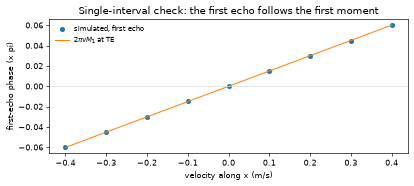

measured slope +0.4702 rad/(m/s),  2 pi M1x = +0.4723  (ratio 0.9957)


In [5]:
VELOCITIES = np.linspace(-0.4, 0.4, 9)
still_x = echoes(SHORT, conventional, 0.0, 'x')[0]
first_echo = SIGN * np.unwrap([
    float(np.angle(echoes(SHORT, conventional, v, 'x')[0] * np.conj(still_x)))
    for v in VELOCITIES
])
m1x = measure(conventional, CENTRE_LINE)['m1_te'][0]

fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.plot(VELOCITIES, first_echo / np.pi, 'o', ms=5, label='simulated, first echo')
ax.plot(VELOCITIES, 2 * np.pi * VELOCITIES * m1x / np.pi, '-', lw=1.2,
        label=r'$2\pi v M_1$ at TE')
ax.axhline(0.0, color='0.85', lw=0.8)
ax.set_xlabel('velocity along x (m/s)')
ax.set_ylabel('first-echo phase (x pi)')
ax.set_title('Single-interval check: the first echo follows the first moment')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

phase_slope = np.polyfit(VELOCITIES, first_echo, 1)[0]
print(f'measured slope {phase_slope:+.4f} rad/(m/s),  2 pi M1x = {2 * np.pi * m1x:+.4f}  '
      f'(ratio {phase_slope / (2 * np.pi * m1x):.4f})')

### A4. The whole train, which is where the physics lives

The single interval is a sanity check. It is not what a bSSFP acquisition experiences, because
nothing is spoiled: transverse coherence survives from one repetition into the next, so a phase
error that *varies* from repetition to repetition perturbs the steady state itself. That is
Bieri's Eq. [1], and it is why their criterion is a phase *increment* rather than a phase.

The experiment below plays the full phase-encode table — so `M1y` really does change from one
repetition to the next — at several velocities along the phase-encode axis, and watches the
signal rather than the phase.

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/3773641142.py:26: SeqCraftWarning: 102 blocks over the vector-norm limit (legal on real amplifiers): conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 140% at 1293.740 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 138% at 1296.110 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 138% at 1300.190 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 136% at 1302.560 ms), conventional_linear_order_probe.bSSFP2DTR, conventional_linear_order_probe.bSSFP2DTR.CartesianLine, conventional_linear_order_probe.bSSFP2DTR.PhaseEncode (slew 136% at 1306.640 ms) (+97 more sites)
  sc.compile(out, opts

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/3773641142.py:26: SeqCraftWarning: 102 blocks over the vector-norm limit (legal on real amplifiers): conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 100% at 1351.790 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 100% at 1358.240 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 101% at 1364.690 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.CartesianLine, conventional_centric_order_probe.bSSFP2DTR.PhaseEncode (slew 101% at 1371.140 ms), conventional_centric_order_probe.bSSFP2DTR, conventional_centric_order_probe.bSSFP2DTR.Cartesi

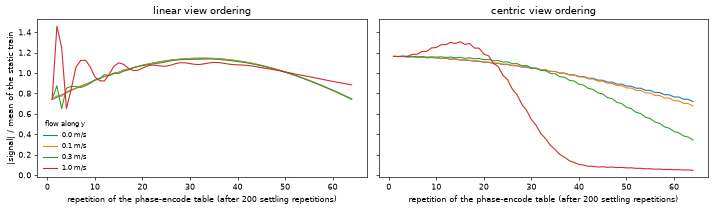

ordering      v (m/s)   mean |S| / static   std / mean  Bieri d phi (deg)
linear           0.00               1.000        0.126               0.00
linear           0.10               1.000        0.125               0.27
linear           0.30               0.997        0.123               0.80
linear           1.00               1.029        0.106               2.66
centric          0.00               1.000        0.134               0.00
centric          0.10               0.992        0.148               8.52
centric          0.30               0.913        0.287              25.57
centric          1.00               0.586        0.888              85.25


In [6]:
# The train has to be IN a steady state before the encoding increment is introduced, or the
# transient swamps what is being measured.  So each file is a settling block at one line --
# constant PE, therefore zero increment, so the magnetisation converges -- followed by the
# phase-encode table.  Only the table part is analysed.
SETTLE = 200

TRAINS = {name: write_train(conventional, f'conventional_{name}_order_probe',
                            [CENTRE_LINE] * SETTLE + list(order))
          for name, order in (('linear', linear), ('centric', centric))}

FLOW = [0.0, 0.1, 0.3, 1.0]            # m/s along y, the phase-encode axis
trains = {name: {v: np.abs(echoes(path, conventional, v, 'y'))[SETTLE:] for v in FLOW}
          for name, path in TRAINS.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, label in zip(axes, trains):
    for v in FLOW:
        s = trains[label][v]
        ax.plot(np.arange(len(s)) + 1, s / trains[label][0.0].mean(), lw=1.3,
                label=f'{v:.1f} m/s')
    ax.set_title(f'{label} view ordering')
    ax.set_xlabel(f'repetition of the phase-encode table (after {SETTLE} settling repetitions)')
axes[0].set_ylabel('|signal| / mean of the static train')
axes[0].legend(frameon=False, fontsize=8, title='flow along y', title_fontsize=8)
fig.tight_layout()
plt.show()

print(f'{"ordering":12}{"v (m/s)":>9}{"mean |S| / static":>20}{"std / mean":>13}'
      f'{"Bieri d phi (deg)":>19}')
for label, order in (('linear', linear), ('centric', centric)):
    d = np.median(phi_increment_deg_per_m_s(order))
    ref = trains[label][0.0].mean()
    for v in FLOW:
        s = trains[label][v]
        print(f'{label:12}{v:9.2f}{s.mean() / ref:20.3f}{s.std() / s.mean():13.3f}'
              f'{d * v:19.2f}')

```text
measurement shows    with linear ordering the mean signal is within 4% of the static train at
                     every velocity up to 1 m/s, where the Eq. [2] increment reaches 2.95 deg.
                     With centric ordering the same velocities give increments of 9 to 94 deg,
                     and the train loses 11% of its mean at 0.3 m/s and 44% at 1 m/s, with the
                     repetition-to-repetition scatter rising from 0.13 to 0.94.

literature           Bieri's simulations put the onset of signal loss near 1 deg of increment
                     and significant perturbation above 2 deg, with a critical velocity of
                     roughly 0.5-1 m/s for standard linear ordering.

interpretation       on this protocol and this single-voxel model the increment, not the
                     velocity, is what predicts degradation -- the same velocities are harmless
                     under one view order and destructive under another, and the crossover sits
                     where Bieri's threshold puts it.  "Balanced SSFP is relatively robust to
                     flow" is therefore a statement about linear ordering at sub-m/s velocities,
                     not a property of the balance condition.
```

A single voxel moving at one velocity is the cleanest way to see the mechanism and the weakest
possible model of a vessel: a real voxel holds a distribution of velocities, and the signal is
the vector sum over it. Nothing here measures that, nor the outflow mechanism Markl and Pelc
describe.

## Part B — explicit gradient-moment nulling

> Conventional balanced SSFP compensates the readout and slice axes within each TR by its own
> symmetry, and leaves the phase-encode axis varying from repetition to repetition. Where that
> variation is large enough to matter — high velocities, or a view order with large k-space
> jumps — Bieri and Scheffler describe two remedies: *pairing* of phase-encode steps, which is
> view ordering and costs nothing, and nulling the first gradient moments, which costs TR.

Pairing needs no change to the repetition and is composed in the acquisition, as §A2 showed.
This section is about the second remedy.

**What the literature asks for.** Bieri and Scheffler are explicit about which interval their
compensation acts on:

> "This compensation nulls the first moment **between excitations**, but does not null the first
> moment between the excitation and echo. However, the flow sensitivity of the b-SSFP signal at
> TE is relatively small and adds only a small phase to the corresponding k-space line. It does
> not perturb steady state."

So the bSSFP condition is $M_1 = 0$ over the RF-to-RF interval. The echo-time first moment is
explicitly *not* what their design nulls, and they give the reason: a phase at TE is a phase on
one k-space line, while a phase that varies between excitations perturbs the steady state.

### B1. What `flow_comp=` currently does

In [7]:
compensated = sc.modules.bSSFP2DTR(**PROTOCOL,
                                   flow_comp=sc.FlowCompensation(axis=('x', 'y', 'z')))

print(f'{"":36}{"x":>13}{"y":>13}{"z":>13}   (s/m)')
for name, kernel in (('conventional', conventional), ('flow_comp=', compensated)):
    for line in (0, NY - 1):
        m = measure(kernel, line)
        print(f'{name:22} ky {line:2d}  M1 at the echo ' + ''.join(f'{v:13.4e}'
                                                                   for v in m['m1_te']))
        print(f'{"":22}        M1 over RF-to-RF' + ''.join(f'{v:13.4e}' for v in m['m1_rr']))
    print()

print(f'{"":22}{"TE (ms)":>10}{"TR (ms)":>10}{"1/TR (Hz)":>12}')
for name, kernel in (('conventional', conventional), ('flow_comp=', compensated)):
    print(f'{name:22}{kernel.te_s * 1e3:10.3f}{kernel.tr_s * 1e3:10.3f}'
          f'{1 / kernel.tr_s:12.1f}')

                                                x            y            z   (s/m)


conventional           ky  0  M1 at the echo    7.5162e-02  -2.9312e-01  -3.7539e-01
                              M1 over RF-to-RF   3.2354e-03   2.3680e-01  -2.2204e-16
conventional           ky 63  M1 at the echo    7.5162e-02   2.8396e-01  -3.7539e-01
                              M1 over RF-to-RF   3.2354e-03  -2.2940e-01  -2.2204e-16

flow_comp=             ky  0  M1 at the echo    4.7833e-05   8.8818e-16  -9.2593e-05
                              M1 over RF-to-RF  -1.8180e-01   8.5568e-01   3.7530e-01
flow_comp=             ky 63  M1 at the echo    4.7833e-05  -8.8818e-16  -9.2593e-05
                              M1 over RF-to-RF  -1.8180e-01  -8.2894e-01   3.7530e-01

                         TE (ms)   TR (ms)   1/TR (Hz)
conventional               3.225     6.450       155.0
flow_comp=                 4.925     9.850       101.5


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

In [8]:
# The quantity Bieri's criterion is about, for both variants.
comp_m1y = {line: measure(compensated, line)['m1_rr'][1] for line in (0, CENTRE_LINE)}
comp_slope = (comp_m1y[CENTRE_LINE] - comp_m1y[0]) / CENTRE_LINE


def increment(slope_value, order):
    return np.degrees(2 * np.pi * np.abs(np.diff(slope_value * np.asarray(order, float))))


print(f'{"":22}{"median d phi, linear order":>30}   deg per (m/s)')
for name, s in (('conventional', slope), ('flow_comp=', comp_slope)):
    print(f'{name:22}{np.median(increment(s, linear)):30.2f}')
ratio = np.median(increment(comp_slope, linear)) / np.median(increment(slope, linear))
print(f'\nratio: flow_comp= is {ratio:.1f}x LARGER on the quantity Bieri Eq. [2] names.')

                          median d phi, linear order   deg per (m/s)
conventional                                    2.66
flow_comp=                                      9.63

ratio: flow_comp= is 3.6x LARGER on the quantity Bieri Eq. [2] names.


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 9 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.joint (axis y) x3, bSSFP2DTR.CartesianLine (axis x) x3
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 111% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (slew 159% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 110% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (slew 157% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 110% at 23.960 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 8 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.CartesianLine (axis x) x3, bSSFP2DT

```text
measurement shows    flow_comp= drives M1 at the echo to near zero on all three axes.  Over the
                     RF-to-RF interval it UNDOES the symmetric structure Part A measured:
                     z goes from 2e-16 to 3.8e-1, x from 3.2e-3 to -1.8e-1, and the
                     phase-encode increment from 2.66 to 9.63 deg/(m/s).

literature           Bieri's criterion is the increment of the RF-to-RF first moment between
                     consecutive repetitions.  Their design nulls the moment between
                     excitations and explicitly does not null it between excitation and echo.

interpretation       what `flow_comp=` provides is **explicit echo-time first-moment
                     compensation**.  It is a real condition and it meets it -- the velocity
                     phase on each acquired line goes away, which is what a phase-contrast
                     style measurement needs.  But it is a different endpoint from the bSSFP
                     one, and reaching it costs the symmetric structure that made the
                     conventional repetition first-order balanced between excitations.
```

So this notebook does not call the result a flow-compensated bSSFP sequence, a motion-robust
bSSFP sequence, or a Bieri-style design. It is echo-time first-moment compensation, and that is
the whole of the claim.

**The waveform is not supposed to resemble Bieri's Fig. 2, and it does not.** That figure is a
design for a different endpoint — the first moment between excitations — and it is organised
symmetrically about the echo for that reason. This one is solving for the moment at the echo, so
asymmetry over the interval is what the requirement produces rather than a flaw in meeting it.

### B2. What it costs, and the other thing TR buys

Explicit compensation lengthens TE and TR. In balanced SSFP a longer TR is not only scan time:
the off-resonance passband is $1/\mathrm{TR}$ wide, so the dark bands move closer together.

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1264582748.py:8: SeqCraftWarning: 8 same-axis gradient merges: bSSFP2DTR.joint (axis z) x3, bSSFP2DTR.CartesianLine (axis x) x3, bSSFP2DTR.joint (axis y) x2
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1264582748.py:8: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (grad 101% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode, bSSFP2DTR.joint (slew 129% at 4.260 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (slew 129% at 14.110 ms), bSSFP2DTR.CartesianLine, bSSFP2DTR.joint (grad 101% at 23.960 ms) (+1 more sites)
  seq = sc.compile(scan, opts)


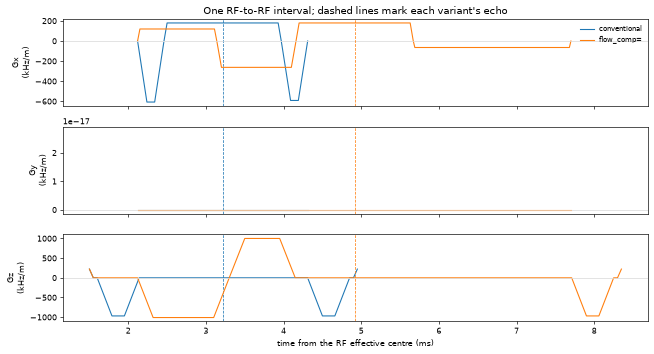

TE  3.225 -> 4.925 ms (+53%)
TR  6.450 -> 9.850 ms (+53%)
band spacing 1/TR  155 -> 102 Hz (-35%)

Bieri report about +50% on minimum TR for their fully compensated 3D scheme.


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6.0), sharex=True)
for kernel, name, colour in ((conventional, 'conventional', 'C0'),
                             (compensated, 'flow_comp=', 'C1')):
    scan = sc.LogicBlock()
    for index in range(3):
        scan.add(index * kernel.tr_s,
                 kernel(line=CENTRE_LINE + index, phase_deg=180.0 * (index % 2)))
    seq = sc.compile(scan, opts)
    c = rf_centres(seq)
    for axis, (ax, label) in enumerate(zip(axes, ('Gx', 'Gy', 'Gz'))):
        t, g = seq.waveforms_and_times()[0][axis]
        inside = (t >= c[0] - 0.4e-3) & (t <= c[1] + 0.1e-3)
        ax.plot((t[inside] - c[0]) * 1e3, g[inside] / 1e3, lw=1.3, color=colour,
                label=name if axis == 0 else None)
        ax.axhline(0.0, color='0.88', lw=0.8)
        ax.axvline(kernel.te_s * 1e3, color=colour, ls='--', lw=0.9)
        ax.set_ylabel(f'{label}\n(kHz/m)')
axes[0].legend(frameon=False, fontsize=8, loc='upper right')
axes[0].set_title("One RF-to-RF interval; dashed lines mark each variant's echo")
axes[-1].set_xlabel('time from the RF effective centre (ms)')
fig.tight_layout()
plt.show()

print(f'TE  {conventional.te_s * 1e3:.3f} -> {compensated.te_s * 1e3:.3f} ms '
      f'(+{(compensated.te_s / conventional.te_s - 1) * 100:.0f}%)')
print(f'TR  {conventional.tr_s * 1e3:.3f} -> {compensated.tr_s * 1e3:.3f} ms '
      f'(+{(compensated.tr_s / conventional.tr_s - 1) * 100:.0f}%)')
print(f'band spacing 1/TR  {1 / conventional.tr_s:.0f} -> {1 / compensated.tr_s:.0f} Hz '
      f'({(1 / compensated.tr_s) / (1 / conventional.tr_s) - 1:+.0%})')
print(f'\nBieri report about +50% on minimum TR for their fully compensated 3D scheme.')

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/3773641142.py:26: SeqCraftWarning: 8 same-axis gradient merges: echo_m1_comp_first_echo_probe.bSSFP2DTR.joint (axis z) x4, echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine (axis x) x4
  sc.compile(out, opts, name=name).write(str(path))


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/3773641142.py:26: SeqCraftWarning: 8 blocks over the vector-norm limit (legal on real amplifiers): echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine, echo_m1_comp_first_echo_probe.bSSFP2DTR.PhaseEncode, echo_m1_comp_first_echo_probe.bSSFP2DTR.joint (grad 101% at 4.260 ms), echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine, echo_m1_comp_first_echo_probe.bSSFP2DTR.PhaseEncode, echo_m1_comp_first_echo_probe.bSSFP2DTR.joint (slew 129% at 4.260 ms), echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine, echo_m1_comp_first_echo_probe.bSSFP2DTR.PhaseEncode, echo_m1_comp_first_echo_probe.bSSFP2DTR.joint (grad 101% at 14.110 ms), echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine, echo_m1_comp_first_echo_probe.bSSFP2DTR.PhaseEncode, echo_m1_comp_first_echo_probe.bSSFP2DTR.joint (slew 129% at 14.110 ms), echo_m1_comp_first_echo_probe.bSSFP2DTR.CartesianLine, echo_m1_comp_first_echo_probe.bSSFP2DTR.PhaseEncode, echo_m1_co

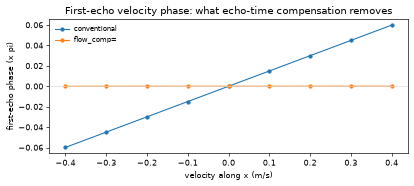

In [10]:
still_x = echoes(SHORT, conventional, 0.0, 'x')[0]
SHORT_C = write_train(compensated, 'echo_m1_comp_first_echo_probe', [CENTRE_LINE] * 4)
still_c = echoes(SHORT_C, compensated, 0.0, 'x')[0]

fig, ax = plt.subplots(figsize=(7.0, 3.2))
for name, path, kernel, still, colour in (
        ('conventional', SHORT, conventional, still_x, 'C0'),
        ('flow_comp=', SHORT_C, compensated, still_c, 'C1')):
    phases = SIGN * np.unwrap([
        float(np.angle(echoes(path, kernel, v, 'x')[0] * np.conj(still))) for v in VELOCITIES])
    ax.plot(VELOCITIES, phases / np.pi, 'o-', ms=4, lw=1.3, color=colour, label=name)
ax.axhline(0.0, color='0.85', lw=0.8)
ax.set_xlabel('velocity along x (m/s)')
ax.set_ylabel('first-echo phase (x pi)')
ax.set_title('First-echo velocity phase: what echo-time compensation removes')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Part C — what Bieri-style compensation would need

Bieri and Scheffler's design nulls the first moment **between excitations**:

```text
over [RF centre n, RF centre n+1]      M0 = 0   and   M1 = 0   on the compensated axes
```

Part A measured how much of that the conventional repetition already satisfies, so what remains
is a short list.

In [11]:
rows = []
for line in (0, CENTRE_LINE, NY - 1):
    m = measure(conventional, line)
    rows.append((line, m['m0_rr'], m['m1_rr']))

print('Bieri-style condition, against the conventional symmetric repetition\n')
print(f'{"axis":6}{"M0 over TR":>14}{"M1 over TR":>16}   verdict')
for axis, name in enumerate('xyz'):
    m0 = max(abs(r[1][axis]) for r in rows)
    m1 = [r[2][axis] for r in rows]
    spread = np.ptp(m1)
    if max(abs(v) for v in m1) < 1e-9:
        verdict = 'met'
    elif spread < 1e-12:
        verdict = f'constant {m1[0]:+.1e}: a constant per-TR phase, which Eq. [1] allows'
    else:
        verdict = f'varies with the line, {min(m1):+.3f} .. {max(m1):+.3f}: NOT met'
    print(f'{name:6}{m0:14.2e}{max(abs(v) for v in m1):16.2e}   {verdict}')

Bieri-style condition, against the conventional symmetric repetition

axis      M0 over TR      M1 over TR   verdict
x           7.60e-13        3.24e-03   constant +3.2e-03: a constant per-TR phase, which Eq. [1] allows
y           0.00e+00        2.37e-01   varies with the line, -0.229 .. +0.237: NOT met
z           2.27e-13        2.22e-16   met


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 138% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 12.560 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 136% at 16.640 ms) (+1 more sites)
  seq = sc.compile(scan, opts)
/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_69872/1151718826.py:33: SeqCraftWarning: 6 blocks over the vector-norm limit (legal on real amplifiers): bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 138% at 3.740 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode (slew 136% at 6.110 ms), bSSFP2DTR, bSSFP2DTR.CartesianLine, bSSFP2DTR.PhaseEncode (slew 140% at 10.190 ms), bSSFP2DTR, bSSFP2DTR.PhaseEncode 

So on this waveform the Bieri condition is already met on the slice axis, and on the readout axis
up to a constant that the steady-state criterion tolerates. **The phase-encode axis is the whole
of the remaining work** — which is what Bieri's Fig. 2a addresses: "Extra gradient moments with
opposite sign … complement PE to null the first-order PE gradient moment within TR."

That is a different waveform from the one `flow_comp=` produces. A blip and its rewind are a
dipole: two lobes of equal area and opposite sign, whose first moment over the interval cannot be
zero while their separation is not. Nulling it needs more lobes on `y`, arranged symmetrically
about the echo so the rest of the structure survives — and it costs TR, which Bieri report at
about +50 % for their 3D scheme.

**It is not implemented here**, and no file in this notebook's `seq/diagnostics/` directory
represents it — the probes are the conventional sequence under different view orders, and the
echo-time compensated variant. The condition is stated and the gap is measured, which is what a
decision needs; inventing the waveform from a reading of a figure is not. Two things are
worth saying about what that decision involves:

- `sc.FlowCompensation` means *echo-time* first-moment nulling across SeqCraft, and that meaning
  is right for a spoiled gradient echo. A between-excitations condition is a different endpoint,
  so it would need its own way of being asked for rather than a redefinition of this one.
- There is a remedy that needs no gradient change at all. Bieri's "pairing" orders the
  phase-encode table so consecutive lines are adjacent, and §A2 measured what that does to the
  increment. Ordering is written in the acquisition, so it is available today — in the loop in
  [`01_build.ipynb`](01_build.ipynb).

The first-echo velocity phase is what `flow_comp=` removes, and it removes it. That is the
condition it states, measured and met.

## Summary

**From the literature**

- Balanced SSFP stays in a steady state only while the per-TR spin phase is *constant* across
  repetitions (Bieri & Scheffler 2005, Eq. [1]). A phase that varies perturbs it.
- In a symmetric 2D scheme the readout and slice gradients are first-order compensated within
  each TR; the phase-encode axis is not, and its repetition-to-repetition increment is their
  Eq. [2].
- Signal loss sets in near 1° of increment, with a critical velocity of roughly 0.5–1 m/s for
  standard linear ordering; non-standard view orders reach it far sooner.
- Their compensation nulls the first moment **between excitations**, not between excitation and
  echo, and they state that the TE sensitivity is small and does not perturb the steady state.
- Flow in balanced SSFP also involves through-slice outflow and effective slice broadening,
  which is a separate mechanism (Markl & Pelc 2004) and is not measured here.

**From measurement on this implementation**

- `M0` over the RF-to-RF interval is zero on all three axes; `M0` at the echo is zero on x and z
  and carries `ky` on y.
- Over the interval, `M1z` is zero to 2e-16 and `M1x` is 3.2e-3 s/m and identical for every line;
  `M1y` varies with the line. That is the structure the literature describes, and it comes from
  arranging each axis symmetrically about the echo rather than from `M0 = 0`.
- The Eq. [2] increment is 2.66°/(m/s) with linear ordering, within range of the ~2°/(m/s) Bieri
  quote for a comparable standard protocol, and about 30× larger with centric ordering.
- A moving single voxel degrades the train in the order the increment predicts: linear ordering
  holds within 3 % of the static train to 1 m/s, centric loses 41 % of its mean at the same
  velocity.
- `flow_comp=` nulls `M1` at the echo by three to four orders of magnitude and undoes the
  symmetric structure over the interval, raising the increment by 3.6×. TE and TR grow ~53 %,
  which narrows the off-resonance band spacing from 155 to 102 Hz.

**Interpretation, scoped**

- "Balanced SSFP is flow-robust" is a statement about linear view ordering at sub-m/s velocities
  on a symmetric protocol. It is not a property of the balance condition, and the same sequence
  with centric ordering is not robust at a tenth of the velocity.
- `flow_comp=` is **explicit echo-time first-moment compensation**. It is not the bSSFP flow
  compensation of Bieri & Scheffler, and this notebook does not claim it is.
- The between-excitations condition is already met on `z`, and on `x` up to a constant the
  steady-state criterion tolerates. What remains is the phase-encode axis, and that waveform is
  not implemented.

## References

1. Bieri O, Scheffler K. *Flow compensation in balanced SSFP sequences.* Magn Reson Med
   2005;54:901–907. — Eqs. [1] and [2], the 1–2° threshold, the 0.5–1 m/s critical velocity, the
   pairing concept, and the statement of which interval the compensation nulls.
2. Markl M, Pelc NJ. *On flow effects in balanced steady-state free precession imaging: pictorial
   description, parameter dependence, and clinical implications.* J Magn Reson Imaging
   2004;20:697–705. — outflow, effective slice broadening, frequency-offset dependence.
3. Scheffler K, Lehnhardt S. *Principles and applications of balanced SSFP techniques.* Eur
   Radiol 2003;13:2409–2418.
4. Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, §9.2
   (gradient moment nulling) and §14.1 (balanced SSFP).